### Building Chatbot With Multiple Tools Using Langgraph

#### Aim
Create a chatbot with tool capabilities from arxiv, wikipedia search and some functions

In [1]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper


In [2]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)


In [3]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=2,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)


In [4]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")



Tavily search Tool

In [5]:
from langchain_community.tools.tavily_search import TavilySearchResults
tavily_search=TavilySearchResults()


C:\Users\ArnavBhatia\AppData\Local\Temp\ipykernel_64256\3700627128.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_search=TavilySearchResults()


In [6]:
tavily_search.invoke("What is the latest research on machine learning?")

[{'title': 'Top Machine Learning Trends in 2025 - GeeksforGeeks',
  'url': 'https://www.geeksforgeeks.org/machine-learning/top-machine-learning-trends/',
  'content': "In conclusion, the future of Machine Learning is incredibly promising and full of potential. As technology continues to grow, we can expect to see even more exciting developments in the field of machine learning that how computers can able to learn and adapt. From the ability to forget data using Machine Unlearning to the convergence of IoT and Machine Learning, these trends are basically reshaping industries and paving the way for new futuristic possibilities. With companies investing heavy amount and time in research and development of this field, the impact of Machine Learning on our lives will only continue to grow even more. To fully utilise machine learning in an increasingly digital world, as we look to 2025 and beyond, we must remain curious and stay abreast of these trends. [...] Top-Machine-Learning-Trends-in-2

In [7]:
tools=[arxiv,wiki,tavily_search]

In [ ]:
from langchain_ollama import  ChatOllama
llm=ChatOllama(model="llama3.2:latest")

llm

ChatOllama(model='llama3.2:latest')

In [13]:
from langchain_core.messages import AIMessage,HumanMessage,SystemMessage
llm_with_tools=llm.bind_tools(tools=tools)
response=llm_with_tools.invoke([HumanMessage(content="What is the latest research on machine learning?")])


In [14]:
response.tool_calls

[{'name': 'arxiv',
  'args': {'query': {'description': 'search query to look up',
    'type': 'string',
    'value': 'latest machine learning research'}},
  'id': '75024acf-eb7d-4826-975a-21172b9e32b7',
  'type': 'tool_call'}]

### entire graph

In [16]:
from  typing_extensions import TypedDict,Literal
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]


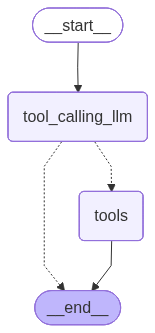

In [29]:
from IPython.display import display,Markdown,Image
from langgraph.graph import START,END,StateGraph
from langgraph.prebuilt import ToolNode,tools_condition


def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}


builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools=tools))

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition)
builder.add_edge("tools",END)

graph=builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [30]:
messages=graph.invoke({"messages":HumanMessage(content="What is attention is all you need")})
print(messages)
for m in messages['messages']:

    m.pretty_print()

{'messages': [HumanMessage(content='What is attention is all you need', additional_kwargs={}, response_metadata={}, id='b0a7e617-a10a-47ab-a3df-b3260eb042eb'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-04-29T11:11:16.1987589Z', 'done': True, 'done_reason': 'stop', 'total_duration': 928943800, 'load_duration': 364002500, 'prompt_eval_count': 349, 'prompt_eval_duration': 235024300, 'eval_count': 25, 'eval_duration': 264371200, 'model_name': 'llama3.2:latest'}, id='lc_run--019dd8ef-9d3a-73c1-b76b-dceb907984a0-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'attention is all you need'}, 'id': 'da40595e-9160-4e78-92a8-c6b22af1eff4', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 349, 'output_tokens': 25, 'total_tokens': 374}), ToolMessage(content='[{"title": "Attention Is All You Need - Wikipedia", "url": "https://en.wikipedia.org/wiki/Attention_Is_All_You_Need", "con

In [31]:
messages=graph.invoke({"messages":HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (ba8f2e4c-fb65-4a65-8d58-3f506c0fdada)
 Call ID: ba8f2e4c-fb65-4a65-8d58-3f506c0fdada
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


In [33]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me latest 10 Ai News")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me latest 10 Ai News
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (268cda43-8012-4e8b-b316-5952e10e74af)
 Call ID: 268cda43-8012-4e8b-b316-5952e10e74af
  Args:
    query: latest 10 ai news
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Top 10 AI Updates in 2026 by Leading Global Companies", "url": "https://www.linkedin.com/pulse/top-10-ai-updates-2026-leading-global-companies-encoresky-jxwyc", "content": "### Inference AI will be a Billion Times Bigger, Unleashing the Next Wave of AI: RAG-Based Models, Agentic Systems, and AI Co-Pilots\n\n### What Ameca, the LLM humanoid, reveals about AI adoption outpacing infrastructure\n\n### Will AI be the next oil?\n\n### Apple's Endgame AI Strategy 2026: Masterclass of the Intelligence Architect\n\n### Y

In [32]:
messages=graph.invoke({"messages":HumanMessage(content="What is machine Learning")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine Learning
================================== Ai Message ==================================
Tool Calls:
  wikipedia (47550978-2471-4f21-9c3f-9c08f33aa1ef)
 Call ID: 47550978-2471-4f21-9c3f-9c08f33aa1ef
  Args:
    query: machine learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit programming language instructions. Within a subdiscipline of machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches 
